In [77]:
from google.colab import files
uploaded = files.upload()
import pandas as pd

df = pd.read_csv("train.csv")

display(df.head())


Saving train.csv to train (6).csv


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [78]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


None

display(df.shape)

In [79]:
display(df.isnull().sum())

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [80]:
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

In [81]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [82]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [83]:
df['Sex'] = df['Sex'].map({'male':0, 'female':1})

In [84]:
df['Embarked'] = df['Embarked'].map({'S':0, 'C':1, 'Q':2})

In [85]:
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)

116


In [86]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])

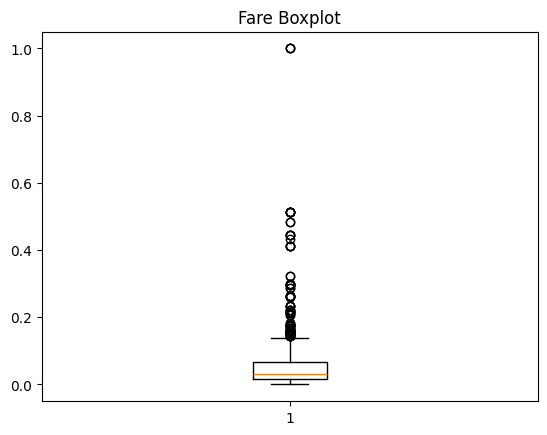

In [87]:
import matplotlib.pyplot as plt

plt.boxplot(df['Fare'])
plt.title("Fare Boxplot")
plt.show()

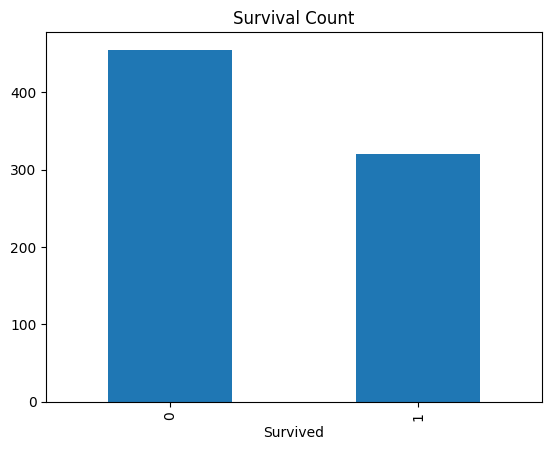

In [88]:
df['Survived'].value_counts().plot(kind='bar')
plt.title("Survival Count")
plt.show()

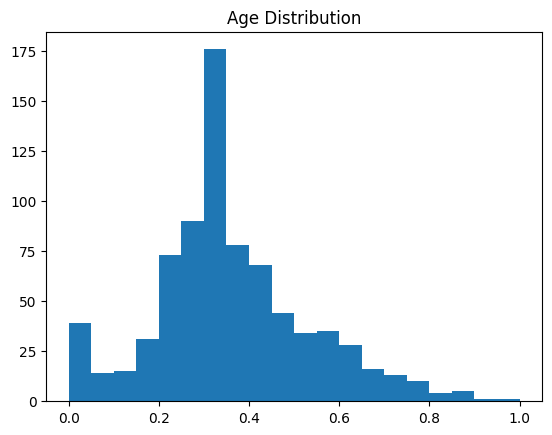

In [89]:
plt.hist(df['Age'], bins=20)
plt.title("Age Distribution")
plt.show()

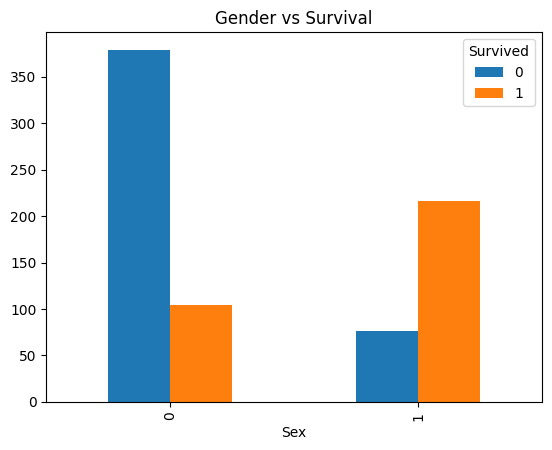

In [90]:
import pandas as pd

pd.crosstab(df['Sex'], df['Survived']).plot(kind='bar')
plt.title("Gender vs Survival")
plt.show()

In [91]:
df.dtypes

,0
Survived,int64
Pclass,int64
Sex,int64
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Embarked,int64


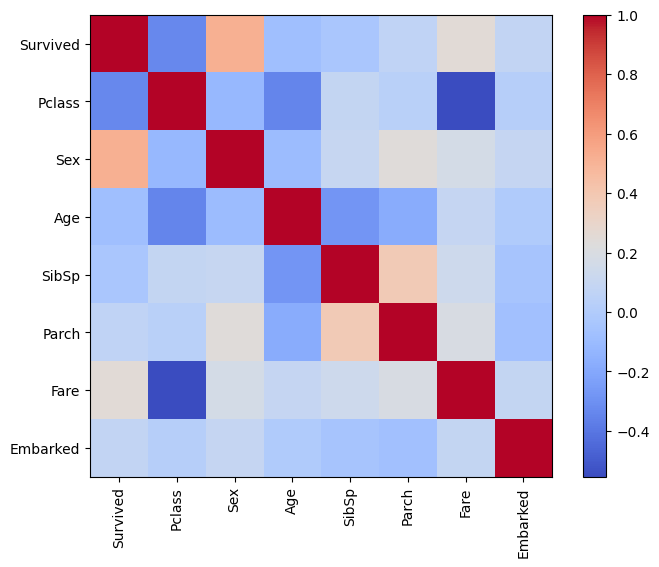

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(df.corr(), cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(df.columns)), df.columns, rotation=90)
plt.yticks(range(len(df.columns)), df.columns)
plt.show()

In [93]:
display(df.columns)

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

In [94]:
df.to_csv("cleaned_titanic.csv", index=False)